In [1]:
import pandas as pd
import numpy as np

# Load datasets
accounts = pd.read_csv("../data/raw/accounts.csv")
products = pd.read_csv("../data/raw/products.csv")
pipeline = pd.read_csv("../data/raw/sales_pipeline.csv")
sales_teams = pd.read_csv("../data/raw/sales_teams.csv")

print("Accounts:", accounts.shape)
print("Products:", products.shape)
print("Pipeline:", pipeline.shape)
print("Sales Teams:", sales_teams.shape)


Accounts: (85, 7)
Products: (7, 3)
Pipeline: (8800, 8)
Sales Teams: (35, 3)


In [2]:
pipeline.columns

Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage',
       'engage_date', 'close_date', 'close_value'],
      dtype='str')

In [3]:
pipeline.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0


In [4]:
pipeline.nunique()

opportunity_id    8800
sales_agent         30
product              7
account             85
deal_stage           4
engage_date        421
close_date         306
close_value       2051
dtype: int64

In [5]:
pipeline['deal_stage'].value_counts()

deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64

In [6]:
# Keep only final outcomes
pipeline_final = pipeline[pipeline['deal_stage'].isin(['Won', 'Lost'])].copy()

print("New shape:", pipeline_final.shape)
print(pipeline_final['deal_stage'].value_counts())


New shape: (6711, 8)
deal_stage
Won     4238
Lost    2473
Name: count, dtype: int64


In [7]:
pipeline_final['target'] = pipeline_final['deal_stage'].map({
    'Won': 1,
    'Lost': 0
})

pipeline_final['target'].value_counts()


target
1    4238
0    2473
Name: count, dtype: int64

In [8]:
master_df = pipeline_final.merge(
    accounts,
    how='left',
    on='account'
)

print(master_df.shape)


(6711, 15)


In [9]:
master_df = master_df.merge(
    products,
    how='left',
    on='product'
)

print(master_df.shape)


(6711, 17)


In [10]:
sales_teams.head()
master_df = master_df.merge(
    sales_teams,
    how='left',
    on='sales_agent'
)

print(master_df.shape)


(6711, 19)


In [11]:
master_df.head()
master_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6711 entries, 0 to 6710
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   opportunity_id    6711 non-null   str    
 1   sales_agent       6711 non-null   str    
 2   product           6711 non-null   str    
 3   account           6711 non-null   str    
 4   deal_stage        6711 non-null   str    
 5   engage_date       6711 non-null   str    
 6   close_date        6711 non-null   str    
 7   close_value       6711 non-null   float64
 8   target            6711 non-null   int64  
 9   sector            6711 non-null   str    
 10  year_established  6711 non-null   int64  
 11  revenue           6711 non-null   float64
 12  employees         6711 non-null   int64  
 13  office_location   6711 non-null   str    
 14  subsidiary_of     1160 non-null   str    
 15  series            5564 non-null   str    
 16  sales_price       5564 non-null   float64
 17  manage

In [12]:
master_df['engage_date'] = pd.to_datetime(master_df['engage_date'])
master_df['close_date'] = pd.to_datetime(master_df['close_date'])

master_df[['engage_date', 'close_date']].dtypes


engage_date    datetime64[us]
close_date     datetime64[us]
dtype: object

In [13]:
master_df['deal_duration_days'] = (
    master_df['close_date'] - master_df['engage_date']
).dt.days

master_df['deal_duration_days'].describe()



count    6711.000000
mean       47.985397
std        41.057665
min         1.000000
25%         8.000000
50%        45.000000
75%        85.000000
max       138.000000
Name: deal_duration_days, dtype: float64

In [14]:
master_df[['close_value', 'revenue', 'employees']].describe()


,close_value,revenue,employees
count,6711.000000,6711.000000,6711.000000
mean,1490.915512,2520.212707,5808.018626
std,2320.670773,2627.849922,6903.156013
min,0.000000,4.540000,9.000000
25%,0.000000,647.180000,1238.000000
50%,472.000000,1698.200000,3502.000000
75%,3225.000000,3027.460000,8274.000000
max,30288.000000,11698.030000,34288.000000


In [15]:
import numpy as np

master_df['log_close_value'] = np.log1p(master_df['close_value'])
master_df['log_revenue'] = np.log1p(master_df['revenue'])
master_df['log_employees'] = np.log1p(master_df['employees'])

master_df[['log_close_value', 'log_revenue', 'log_employees']].describe()


,log_close_value,log_revenue,log_employees
count,6711.000000,6711.000000,6711.000000
mean,4.362822,7.142489,7.902075
std,3.576244,1.487347,1.538064
min,0.000000,1.711995,2.302585
25%,0.000000,6.474168,7.122060
50%,6.159095,7.437913,8.161375
75%,8.078998,8.015810,9.020994
max,10.318540,9.367261,10.442580


In [16]:
import numpy as np

master_df['log_close_value'] = np.log1p(master_df['close_value'])
master_df['log_revenue'] = np.log1p(master_df['revenue'])
master_df['log_employees'] = np.log1p(master_df['employees'])

master_df[['log_close_value', 'log_revenue', 'log_employees']].describe()


,log_close_value,log_revenue,log_employees
count,6711.000000,6711.000000,6711.000000
mean,4.362822,7.142489,7.902075
std,3.576244,1.487347,1.538064
min,0.000000,1.711995,2.302585
25%,0.000000,6.474168,7.122060
50%,6.159095,7.437913,8.161375
75%,8.078998,8.015810,9.020994
max,10.318540,9.367261,10.442580


In [17]:
# Extract useful date features

master_df['engage_year'] = master_df['engage_date'].dt.year
master_df['engage_month'] = master_df['engage_date'].dt.month

master_df['close_year'] = master_df['close_date'].dt.year
master_df['close_month'] = master_df['close_date'].dt.month

master_df[['engage_year', 'engage_month', 'close_year', 'close_month']].head()


,engage_year,engage_month,close_year,close_month
0,2016,10,2017,3
1,2016,10,2017,3
2,2016,10,2017,3
3,2016,10,2017,3
4,2016,10,2017,3


In [18]:
drop_cols = [
    'opportunity_id',
    'account',
    'deal_stage',
    'engage_date',
    'close_date',
    'close_value',
    'log_close_value'
]

model_df = master_df.drop(columns=drop_cols)

model_df.shape


(6711, 20)

In [19]:
model_df.isnull().sum()


sales_agent              0
product                  0
target                   0
sector                   0
year_established         0
revenue                  0
employees                0
office_location          0
subsidiary_of         5551
series                1147
sales_price           1147
manager                  0
regional_office          0
deal_duration_days       0
log_revenue              0
log_employees            0
engage_year              0
engage_month             0
close_year               0
close_month              0
dtype: int64

In [20]:
# Drop weak high-missing column
model_df = model_df.drop(columns=['subsidiary_of'])

# Fill categorical missing
model_df['series'] = model_df['series'].fillna('Unknown')

# Fill numeric missing
model_df['sales_price'] = model_df['sales_price'].fillna(
    model_df['sales_price'].median()
)

# Confirm no missing values
model_df.isnull().sum()


sales_agent           0
product               0
target                0
sector                0
year_established      0
revenue               0
employees             0
office_location       0
series                0
sales_price           0
manager               0
regional_office       0
deal_duration_days    0
log_revenue           0
log_employees         0
engage_year           0
engage_month          0
close_year            0
close_month           0
dtype: int64

In [21]:
# Separate X and y
X = model_df.drop(columns=['target'])
y = model_df['target']

X.shape, y.shape


((6711, 18), (6711,))

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((5368, 18), (1343, 18))

In [23]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)


Categorical: ['sales_agent', 'product', 'sector', 'office_location', 'series', 'manager', 'regional_office']
Numeric: ['year_established', 'revenue', 'employees', 'sales_price', 'deal_duration_days', 'log_revenue', 'log_employees', 'engage_year', 'engage_month', 'close_year', 'close_month']


/var/folders/52/nxdkt68n6wgd1y78q3nlxd_80000gn/T/ipykernel_88860/1965274036.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


In [24]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


In [25]:
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])


In [26]:
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [27]:
from sklearn.metrics import classification_report, f1_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


F1 Score: 0.7688723205964585
ROC-AUC: 0.5473997045931008

Classification Report:

              precision    recall  f1-score   support

           0       0.49      0.04      0.08       495
           1       0.64      0.97      0.77       848

    accuracy                           0.63      1343
   macro avg       0.56      0.51      0.43      1343
weighted avg       0.58      0.63      0.52      1343



In [28]:
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])


In [29]:
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [30]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))


F1 Score: 0.5662407531943511
ROC-AUC: 0.5466278349533067
              precision    recall  f1-score   support

           0       0.39      0.56      0.46       495
           1       0.66      0.50      0.57       848

    accuracy                           0.52      1343
   macro avg       0.53      0.53      0.51      1343
weighted avg       0.56      0.52      0.53      1343



In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print(classification_report(y_test, y_pred_rf))


F1 Score: 0.7268885367142103
ROC-AUC: 0.5732323232323232
              precision    recall  f1-score   support

           0       0.46      0.28      0.35       495
           1       0.66      0.81      0.73       848

    accuracy                           0.62      1343
   macro avg       0.56      0.55      0.54      1343
weighted avg       0.59      0.62      0.59      1343



In [32]:
def generate_conversation(row):
    duration = row['deal_duration_days']
    sector = row['sector']
    product = row['product']
    revenue = row['revenue']
    
    if row['target'] == 1:
        return (
            f"The client from the {sector} sector showed strong engagement "
            f"over {duration} days regarding the {product}. "
            f"The company with revenue {revenue} responded positively and "
            f"agreed to proceed after negotiations."
        )
    else:
        return (
            f"The prospect in the {sector} sector had limited interaction "
            f"over {duration} days for the {product}. "
            f"The company with revenue {revenue} expressed concerns "
            f"and did not move forward."
        )


In [33]:
model_df['conversation_text'] = model_df.apply(generate_conversation, axis=1)

model_df[['conversation_text', 'target']].head()


,conversation_text,target
0,The client from the retail sector showed stron...,1
1,The client from the medical sector showed stro...,1
2,The client from the retail sector showed stron...,1
3,The client from the software sector showed str...,1
4,The client from the services sector showed str...,1


In [34]:
def generate_conversation(row):
    duration = row['deal_duration_days']
    sector = row['sector']
    product = row['product']
    revenue = row['revenue']
    
    duration_desc = (
        "extended discussions" if duration > 100 
        else "brief discussions"
    )
    
    revenue_desc = (
        "large enterprise" if revenue > 3000 
        else "mid-sized organization"
    )
    
    return (
        f"A {revenue_desc} from the {sector} sector engaged in "
        f"{duration_desc} regarding the {product}. "
        f"Several meetings were conducted to evaluate pricing, "
        f"implementation timelines, and expected ROI."
    )


In [35]:
model_df['conversation_text'] = model_df.apply(generate_conversation, axis=1)

model_df[['conversation_text', 'target']].head()


,conversation_text,target
0,A mid-sized organization from the retail secto...,1
1,A large enterprise from the medical sector eng...,1
2,A mid-sized organization from the retail secto...,1
3,A mid-sized organization from the software sec...,1
4,A mid-sized organization from the services sec...,1


In [36]:
X_text = model_df['conversation_text']
y = model_df['target']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

text_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000))
])

text_model.fit(X_train_text, y_train)

y_pred_text = text_model.predict(X_test_text)
y_prob_text = text_model.predict_proba(X_test_text)[:, 1]

from sklearn.metrics import classification_report, f1_score, roc_auc_score

print("F1 Score:", f1_score(y_test, y_pred_text))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_text))

print(classification_report(y_test, y_pred_text))


F1 Score: 0.7740757644910999
ROC-AUC: 0.5412009243377167
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       495
           1       0.63      1.00      0.77       848

    accuracy                           0.63      1343
   macro avg       0.32      0.50      0.39      1343
weighted avg       0.40      0.63      0.49      1343



/Users/amankumar/Desktop/predictive-sales project/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/amankumar/Desktop/predictive-sales project/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/amankumar/Desktop/predictive-sales project/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

In [38]:
X_full = model_df.drop(columns=['target'])
y = model_df['target']


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

fusion_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('text', TfidfVectorizer(max_features=3000), 'conversation_text')
    ]
)


In [40]:
fusion_model = Pipeline([
    ('preprocessing', fusion_preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])


In [41]:
from sklearn.model_selection import train_test_split

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [42]:
fusion_model.fit(X_train_full, y_train)

y_pred_fusion = fusion_model.predict(X_test_full)
y_prob_fusion = fusion_model.predict_proba(X_test_full)[:, 1]

print("F1 Score:", f1_score(y_test, y_pred_fusion))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_fusion))
print(classification_report(y_test, y_pred_fusion))


F1 Score: 0.5675857431069267
ROC-AUC: 0.548189441585668
              precision    recall  f1-score   support

           0       0.39      0.56      0.46       495
           1       0.66      0.50      0.57       848

    accuracy                           0.52      1343
   macro avg       0.53      0.53      0.52      1343
weighted avg       0.56      0.52      0.53      1343



In [43]:
def generate_conversation(row):
    duration = row['deal_duration_days']
    sector = row['sector']
    product = row['product']
    revenue = row['revenue']
    
    # Revenue category
    if revenue > 4000:
        revenue_desc = "enterprise-level organization"
        focus_area = "long-term scalability and compliance requirements"
    elif revenue > 1500:
        revenue_desc = "mid-market company"
        focus_area = "cost optimization and integration planning"
    else:
        revenue_desc = "growing business"
        focus_area = "initial adoption and pricing flexibility"
    
    # Duration category
    if duration > 120:
        engagement_desc = "multiple strategic discussions"
    elif duration > 60:
        engagement_desc = "several follow-up meetings"
    else:
        engagement_desc = "brief evaluation calls"
    
    return (
        f"A {revenue_desc} in the {sector} sector had {engagement_desc} "
        f"regarding the {product}. Discussions focused on {focus_area}, "
        f"implementation timelines, and expected operational impact."
    )



In [44]:
model_df['conversation_text'] = model_df.apply(generate_conversation, axis=1)

model_df[['conversation_text', 'target']].head()



,conversation_text,target
0,A growing business in the retail sector had mu...,1
1,A mid-market company in the medical sector had...,1
2,A growing business in the retail sector had mu...,1
3,A mid-market company in the software sector ha...,1
4,A growing business in the services sector had ...,1


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

X_text = model_df['conversation_text']
y = model_df['target']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

text_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

text_model.fit(X_train_text, y_train)

y_pred_text = text_model.predict(X_test_text)
y_prob_text = text_model.predict_proba(X_test_text)[:, 1]

print("TEXT MODEL RESULTS")
print("F1 Score:", f1_score(y_test, y_pred_text))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_text))
print(classification_report(y_test, y_pred_text))


TEXT MODEL RESULTS
F1 Score: 0.5763175906913073
ROC-AUC: 0.5650478845054316
              precision    recall  f1-score   support

           0       0.42      0.61      0.49       495
           1       0.69      0.50      0.58       848

    accuracy                           0.54      1343
   macro avg       0.55      0.55      0.54      1343
weighted avg       0.59      0.54      0.55      1343



In [46]:
X_full = model_df.drop(columns=['target'])
y = model_df['target']

from sklearn.model_selection import train_test_split

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

fusion_model = Pipeline([
    ('preprocessing', fusion_preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

fusion_model.fit(X_train_full, y_train)

y_pred_fusion = fusion_model.predict(X_test_full)
y_prob_fusion = fusion_model.predict_proba(X_test_full)[:, 1]

print("FUSION MODEL RESULTS")
print("F1 Score:", f1_score(y_test, y_pred_fusion))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_fusion))
print(classification_report(y_test, y_pred_fusion))


FUSION MODEL RESULTS
F1 Score: 0.5798263193052772
ROC-AUC: 0.5458083190394512
              precision    recall  f1-score   support

           0       0.40      0.57      0.47       495
           1       0.67      0.51      0.58       848

    accuracy                           0.53      1343
   macro avg       0.54      0.54      0.53      1343
weighted avg       0.57      0.53      0.54      1343



In [47]:
from scipy.stats import skew

numeric_features = [
    'close_value',
    'revenue',
    'employees',
    'deal_duration_days'
]

for col in numeric_features:
    print(f"{col} skewness:", skew(master_df[col]))


close_value skewness: 3.5725794966760915
revenue skewness: 1.6870720099348488
employees skewness: 2.2930070649197463
deal_duration_days skewness: 0.30554749690432026


In [48]:
class_counts = model_df['target'].value_counts(normalize=True)
print(class_counts)


target
1    0.631501
0    0.368499
Name: proportion, dtype: float64


In [49]:
imbalance_ratio = class_counts[1] / class_counts[0]
print("Imbalance ratio (Won/Lost):", imbalance_ratio)


Imbalance ratio (Won/Lost): 1.7137080469065913


In [50]:
model_df['close_year'].value_counts()
model_df['close_month'].value_counts().sort_index()


close_month
3     647
4     586
5     805
6     641
7     627
8     785
9     635
10    566
11    768
12    651
Name: count, dtype: int64

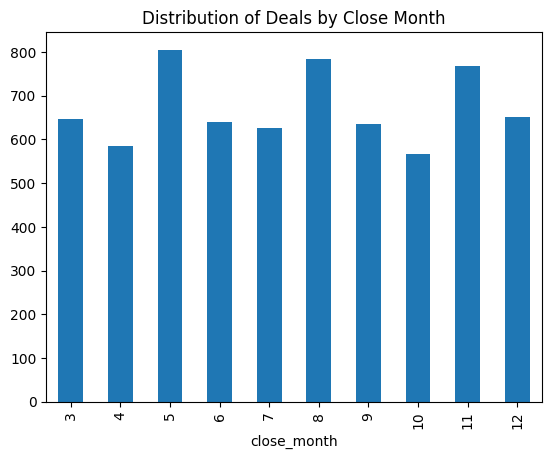

In [51]:
import matplotlib.pyplot as plt

model_df['close_month'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Deals by Close Month")
plt.show()


In [52]:
import numpy as np

corr_df = model_df[numeric_cols + ['target']].corr()

corr_df['target'].sort_values(ascending=False)


target                1.000000
deal_duration_days    0.121059
engage_month          0.003311
year_established     -0.008012
employees            -0.008390
log_employees        -0.010096
sales_price          -0.010606
log_revenue          -0.010833
revenue              -0.012270
close_month          -0.012719
engage_year          -0.085115
close_year                 NaN
Name: target, dtype: float64

In [53]:
for col in categorical_cols:
    print(col, model_df[col].nunique())


sales_agent 30
product 7
sector 10
office_location 15
series 4
manager 6
regional_office 3


In [54]:
sector_win_rate = model_df.groupby('sector')['target'].mean().sort_values(ascending=False)
print(sector_win_rate)


sector
marketing             0.648475
entertainment         0.646766
software              0.639205
technolgy             0.634216
services              0.633523
retail                0.630624
employment            0.625874
telecommunications    0.625000
medical               0.623158
finance               0.611746
Name: target, dtype: float64


In [55]:
win_rate_by_year = model_df.groupby('close_year')['target'].mean()
print(win_rate_by_year)


close_year
2017    0.631501
Name: target, dtype: float64


In [56]:
agent_win_rate = model_df.groupby('sales_agent')['target'].mean().sort_values()
print(agent_win_rate)


sales_agent
Lajuana Vencill       0.549784
Markita Hansen        0.572687
Donn Cantrell         0.574545
Gladys Colclough      0.581897
Niesha Huffines       0.600000
Daniell Hammack       0.609626
Garret Kinder         0.609756
Zane Levy             0.616858
Anna Snelling         0.619048
Kary Hendrixson       0.623881
Cassey Cress          0.624521
Marty Freudenburg     0.628866
Darcel Schlecht       0.631103
Violet Mclelland      0.632124
Elease Gluck          0.634921
Vicki Laflamme        0.636888
Kami Bicknell         0.639706
Rosie Papadopoulos    0.644628
Jonathan Berthelot    0.647727
Reed Clapper          0.654008
Rosalina Dieter       0.654545
Corliss Cosme         0.655022
James Ascencio        0.655340
Boris Faz             0.660131
Moses Frase           0.661538
Versie Hillebrand     0.666667
Cecily Lampkin        0.668750
Wilburn Farren        0.696203
Maureen Marcano       0.699531
Hayden Neloms         0.703947
Name: target, dtype: float64


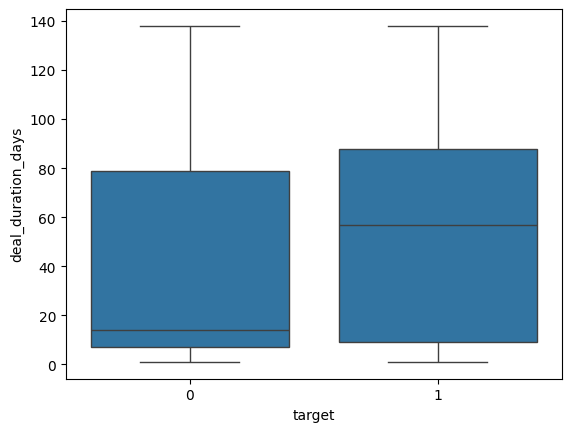

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='target', y='deal_duration_days', data=model_df)
plt.show()


In [58]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])


In [59]:
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBOOST RESULTS")
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBOOST RESULTS
F1 Score: 0.7233138608603292
ROC-AUC: 0.6312976462740614
              precision    recall  f1-score   support

           0       0.46      0.28      0.35       495
           1       0.66      0.80      0.72       848

    accuracy                           0.61      1343
   macro avg       0.56      0.54      0.54      1343
weighted avg       0.58      0.61      0.59      1343



In [60]:
results = {
    "Logistic": 0.546,
    "RandomForest": 0.573,
    "Text Only": 0.565,
    "Fusion": 0.546,
    "XGBoost": roc_auc_score(y_test, y_prob_xgb)
}

print(results)


{'Logistic': 0.546, 'RandomForest': 0.573, 'Text Only': 0.565, 'Fusion': 0.546, 'XGBoost': 0.6312976462740614}


In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__n_estimators': [200, 300, 400]
}

grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 300}
Best CV ROC-AUC: 0.6512555446226401


In [62]:
best_xgb = grid_search.best_estimator_

y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print("TUNED XGBOOST RESULTS")
print("F1 Score:", f1_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))
print(classification_report(y_test, y_pred_best))


TUNED XGBOOST RESULTS
F1 Score: 0.7737765466297323
ROC-AUC: 0.6579688393367638
              precision    recall  f1-score   support

           0       0.60      0.03      0.06       495
           1       0.64      0.99      0.77       848

    accuracy                           0.64      1343
   macro avg       0.62      0.51      0.42      1343
weighted avg       0.62      0.64      0.51      1343



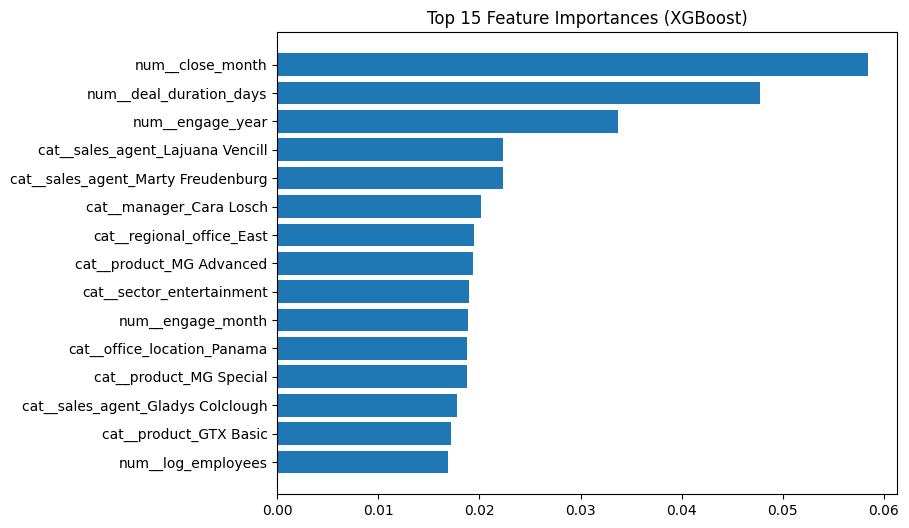

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names after preprocessing
feature_names = best_xgb.named_steps['preprocessing'].get_feature_names_out()

importances = best_xgb.named_steps['clf'].feature_importances_

# Sort top 15
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()


In [64]:
import pandas as pd

misclassified = X_test.copy()
misclassified['true'] = y_test.values
misclassified['pred'] = y_pred_best

errors = misclassified[misclassified['true'] != misclassified['pred']]

print("Number of misclassified samples:", len(errors))
errors.head()


Number of misclassified samples: 490


,sales_agent,product,sector,year_established,revenue,employees,office_location,series,sales_price,manager,regional_office,deal_duration_days,log_revenue,log_employees,engage_year,engage_month,close_year,close_month,true,pred
4162,Lajuana Vencill,GTX Plus Basic,software,1982,4618.00,10083,United States,GTX,1096.0,Dustin Brinkmann,Central,11,8.437934,9.218705,2017,7,2017,7,1,0
615,Daniell Hammack,MG Advanced,medical,2017,4.54,9,United States,MG,3393.0,Rocco Neubert,East,88,1.711995,2.302585,2017,2,2017,5,0,1
765,Darcel Schlecht,GTXPro,technolgy,1997,8170.38,16499,Korea,Unknown,1096.0,Melvin Marxen,Central,91,9.008393,9.711116,2017,2,2017,5,0,1
5473,Maureen Marcano,GTX Basic,entertainment,1992,324.19,978,United States,GTX,550.0,Summer Sewald,West,52,5.784410,6.886532,2017,9,2017,11,0,1
1368,Anna Snelling,MG Special,finance,1991,2819.50,7227,United States,MG,55.0,Dustin Brinkmann,Central,60,7.944669,8.885718,2017,3,2017,5,0,1


In [65]:
errors['sector'].value_counts()


sector
retail                96
medical               78
technolgy             75
software              47
finance               42
marketing             37
services              34
telecommunications    31
entertainment         25
employment            25
Name: count, dtype: int64

In [66]:
import numpy as np

probs = y_prob_best

thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)


Best Threshold: 0.5081632653061224
Best F1: 0.7764378478664193


In [67]:
# Company age (proxy for maturity)
model_df['company_age'] = model_df['engage_year'] - model_df['year_established']

# Revenue per employee
model_df['revenue_per_employee'] = model_df['revenue'] / model_df['employees']

# Interaction features
model_df['duration_x_revenue'] = model_df['deal_duration_days'] * model_df['log_revenue']
model_df['duration_x_employees'] = model_df['deal_duration_days'] * model_df['log_employees']


In [68]:
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()

# Manually add new features
numeric_cols.extend([
    'company_age',
    'revenue_per_employee',
    'duration_x_revenue',
    'duration_x_employees'
])


In [69]:
X_updated = model_df.drop(columns=['target'])
y = model_df['target']

from sklearn.model_selection import train_test_split

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_updated, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [70]:
categorical_cols = X_updated.select_dtypes(include='object').columns.tolist()
numeric_cols = X_updated.select_dtypes(exclude='object').columns.tolist()

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_updated = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


/var/folders/52/nxdkt68n6wgd1y78q3nlxd_80000gn/T/ipykernel_88860/1592853135.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_updated.select_dtypes(include='object').columns.tolist()


In [71]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report

xgb_updated = Pipeline([
    ('preprocessing', preprocessor_updated),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_updated.fit(X_train_u, y_train_u)

y_pred_u = xgb_updated.predict(X_test_u)
y_prob_u = xgb_updated.predict_proba(X_test_u)[:, 1]

print("UPDATED XGBOOST RESULTS")
print("F1 Score:", f1_score(y_test_u, y_pred_u))
print("ROC-AUC:", roc_auc_score(y_test_u, y_prob_u))
print(classification_report(y_test_u, y_pred_u))


UPDATED XGBOOST RESULTS
F1 Score: 0.7716390423572744
ROC-AUC: 0.6546550409757956
              precision    recall  f1-score   support

           0       0.47      0.02      0.04       495
           1       0.63      0.99      0.77       848

    accuracy                           0.63      1343
   macro avg       0.55      0.50      0.40      1343
weighted avg       0.57      0.63      0.50      1343

